In [1]:
import os
import sys
import numpy as np
import h5py
from tqdm import tqdm
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.mplot3d.art3d import Line3DCollection

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

# Set rendering backend based on platform
# macOS: use glfw (native OpenGL)
# Linux: use osmesa (software rendering) or egl (headless GPU)
if sys.platform == "darwin":
    os.environ["MUJOCO_GL"] = "glfw"
    print("Using macOS with GLFW rendering")
else:
    # Change this to egl if GPU is available on Linux
    os.environ["MUJOCO_GL"] = "osmesa"
    print("Using Linux with osmesa rendering")

import mediapy as media
from pathlib import Path

from track_mjx.agent import checkpointing
from track_mjx.analysis import rollout, render

import huggingface_hub as hf_hub

# matplotlib parameters 
mpl.rcParams["figure.facecolor"] = "w"
mpl.rcParams["figure.dpi"] = 150
mpl.rcParams["savefig.dpi"] = 600
mpl.rcParams["savefig.transparent"] = True
mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["Arial"]
mpl.rcParams["font.size"] = 8
mpl.rcParams["axes.titlesize"] = "xx-large"  # medium, large, x-large, xx-large
# This might be necessary to export to PDF without messing up the text:
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.style.use("seaborn-v0_8-deep")

Using Linux with osmesa rendering


In [14]:
hf_checkpoint_path = "arm/joint-reward-only"
model_local_dir = Path.cwd().parent / "model_checkpoints"

# Download model from model repo
model_download_dir = hf_hub.snapshot_download(
    repo_id="talmolab/MIMIC-MJX", 
    repo_type="model", # download from model repo
    allow_patterns=hf_checkpoint_path + "/*", # path with model id
    local_dir=model_local_dir
)
print(f"Downloaded model to {model_download_dir}")

/root/miniforge3/envs/track_mjx/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Fetching 23 files: 100%|██████████| 23/23 [00:00<00:00, 29.36it/s]

Downloaded model to /root/vast/eric/track-mjx/model_checkpoints


In [15]:
import huggingface_hub as hf_hub
from pathlib import Path

# Download all mouse_arm data files
data_local_dir = Path.cwd().parent / "data"
data_download_dir = hf_hub.snapshot_download(
    repo_id="talmolab/MIMIC-MJX", 
    repo_type="dataset", # download from dataset repo
    allow_patterns="data/mouse_arm/*.h5", # download all h5 files in mouse_arm folder
    local_dir=data_local_dir
)
print(f"Downloaded all mouse_arm data to {data_download_dir}")

# List downloaded files
mouse_arm_dir = Path(data_download_dir) / "mouse_arm"
h5_files = list(mouse_arm_dir.glob("*.h5"))

# Print found filenames (for debugging)
#print(f"Found {len(h5_files)} H5 files:")
#for file in sorted(h5_files):
#    print(f"  - {file.name}")

Fetching 46 files: 100%|██████████| 46/46 [00:00<00:00, 691.83it/s]

Downloaded all mouse_arm data to /root/vast/eric/track-mjx/data


In [16]:
# replace with your checkpoint path
ckpt_path = model_local_dir / hf_checkpoint_path

ckpt = checkpointing.load_checkpoint_for_eval(ckpt_path)
cfg = ckpt["cfg"]

# Update the data path to the downloaded data
cfg.data_path = Path(data_download_dir) / "mouse_arm"

#TEMP: add max_start_frames to cfg to support older checkpoints
cfg.env_config.env_args.max_start_frame = 0

Loading checkpoint from /root/vast/eric/track-mjx/model_checkpoints/arm/joint-reward-only at step 7


In [18]:
# replace with your checkpoint path
ckpt_path = model_local_dir / hf_checkpoint_path

ckpt = checkpointing.load_checkpoint_for_eval(ckpt_path)
cfg = ckpt["cfg"]

# Update the data path to include all H5 files as comma-separated string
mouse_arm_dir = Path(data_download_dir) / "mouse_arm"
h5_files = list(mouse_arm_dir.glob("*.h5"))
if h5_files:
    # Create comma-separated list of all files (like in the original config)
    cfg.data_path = ",".join(str(f) for f in sorted(h5_files))
    print(f"Using {len(h5_files)} data files")
else:
    print("No H5 files found!")

print(f"Data path: {cfg.data_path}")

Loading checkpoint from /root/vast/eric/track-mjx/model_checkpoints/arm/joint-reward-only at step 7
Using 46 data files
Data path: /root/vast/eric/track-mjx/data/mouse_arm/A36-1_2023-07-18_16-54-01_lightOff_trial01_ik.h5,/root/vast/eric/track-mjx/data/mouse_arm/A36-1_2023-07-18_16-54-01_lightOff_trial04_ik.h5,/root/vast/eric/track-mjx/data/mouse_arm/A36-1_2023-07-18_16-54-01_lightOff_trial09_ik.h5,/root/vast/eric/track-mjx/data/mouse_arm/A36-1_2023-07-18_16-54-01_lightOff_trial10_ik.h5,/root/vast/eric/track-mjx/data/mouse_arm/A36-1_2023-07-18_16-54-01_lightOff_trial13_ik.h5,/root/vast/eric/track-mjx/data/mouse_arm/A36-1_2023-07-18_16-54-01_lightOff_trial15_ik.h5,/root/vast/eric/track-mjx/data/mouse_arm/A36-1_2023-07-18_16-54-01_lightOff_trial16_ik.h5,/root/vast/eric/track-mjx/data/mouse_arm/A36-1_2023-07-18_16-54-01_lightOff_trial17_ik.h5,/root/vast/eric/track-mjx/data/mouse_arm/A36-1_2023-07-18_16-54-01_lightOff_trial19_ik.h5,/root/vast/eric/track-mjx/data/mouse_arm/A36-1_2023-07-18_1

In [19]:
# create environment and rollout generator
env = rollout.create_environment(cfg)
inference_fn = checkpointing.load_inference_fn(cfg, ckpt["policy"])
generate_rollout = rollout.create_rollout_generator(
    cfg, 
    env, 
    inference_fn, 
    log_activations=True, 
    log_metrics=True, 
    log_sensor_data=True,
)

In [24]:
# generate a single rollout
single_rollout = generate_rollout(clip_idx=3)

In [25]:
# render single rollout 
frames, realtime_framerate = render.render_rollout(
    cfg, 
    single_rollout, 
    height=480,
    width=640,
)

# save the video to disk
media.write_video(Path(ckpt_path) / "rollout.mp4", frames, fps=realtime_framerate)
media.show_video(frames, fps=realtime_framerate/2)

MuJoCo Rendering with Ghost Model...
Rendering every 1 steps; realtime fps: 500


100%|██████████| 200/200 [00:35<00:00,  5.59it/s]


This browser does not support the video tag.


In [ ]:
# Debug: Check the structure of a single rollout first
print("Examining rollout structure...")
single_rollout = generate_rollout(clip_idx=0)
print("Keys in rollout:", list(single_rollout.keys()))

# if 'activations' in single_rollout:
#     print("Keys in activations:", list(single_rollout['activations'].keys()))
    
#     if 'encoder' in single_rollout['activations']:
#         print("Keys in encoder activations:", list(single_rollout['activations']['encoder'].keys()))
    
#     if 'decoder' in single_rollout['activations']:
#         print("Keys in decoder activations:", list(single_rollout['activations']['decoder'].keys()))
    
#     # Check for intentions in activations
#     if 'intention' in single_rollout['activations']:
#         print("Found intentions in activations!")
#         print("Intentions shape:", single_rollout['activations']['intention'].shape)
#     else:
#         print("No intentions found directly in activations")
        
#     # Check for any intention-related keys
#     intention_keys = [key for key in single_rollout['activations'].keys() if 'intention' in key.lower()]
#     if intention_keys:
#         print("Found intention-related keys:", intention_keys)
#         for key in intention_keys:
#             print(f"  {key} shape:", single_rollout['activations'][key].shape)

# Generate all rollouts
print("\nGenerating rollouts for all clips...")
all_rollouts = {}
num_clips = 46  # Total number of clips

for clip_idx in tqdm(range(num_clips), desc="Generating rollouts"):
    try:
        rollout_data = generate_rollout(clip_idx=clip_idx)
        all_rollouts[clip_idx] = rollout_data
    except Exception as e:
        print(f"Failed to generate rollout for clip {clip_idx}: {e}")

print(f"Successfully generated {len(all_rollouts)} rollouts")

# Extract data for analysis
print("Extracting rollout data...")
actions_data = []  # Will use 'ctrl'
encoder_activations = {
    'layer_0': [],
    'layer_1': [], 
    'layer_2': []
}
decoder_activations = {
    'layer_0': [],
    'layer_1': [],
    'layer_2': []
}
intentions_data = []
qpos_data = []
ref_qpos_data = []
rewards_data = []  # Will use 'state_rewards'

# Extract all data from rollouts
for clip_idx in sorted(all_rollouts.keys()):
    rollout = all_rollouts[clip_idx]
    
    # Get first 50 timesteps
    n_timesteps = min(50, rollout['activations']['encoder']['layer_0'].shape[0])
    
    # Extract all rollout data using correct keys
    actions_data.append(rollout['ctrl'][:n_timesteps])  # actions = ctrl
    qpos_data.append(rollout['qposes_rollout'][:n_timesteps])
    ref_qpos_data.append(rollout['qposes_ref'][:n_timesteps])
    rewards_data.append(rollout['state_rewards'][:n_timesteps])  # rewards = state_rewards
    
    # Extract intentions from activations (correct location)
    if 'activations' in rollout and 'intention' in rollout['activations']:
        intentions_data.append(rollout['activations']['intention'][:n_timesteps])
    else:
        print(f"Warning: No intentions found in activations for clip {clip_idx}")
        # Create placeholder with expected shape
        intentions_data.append(np.zeros((n_timesteps, 60)))  # Default intention size
    
    # Extract activations by layer
    for layer in ['layer_0', 'layer_1', 'layer_2']:
        encoder_activations[layer].append(rollout['activations']['encoder'][layer][:n_timesteps])
        decoder_activations[layer].append(rollout['activations']['decoder'][layer][:n_timesteps])

# Convert to numpy arrays
actions_data = np.array(actions_data)
intentions_data = np.array(intentions_data)
qpos_data = np.array(qpos_data)
ref_qpos_data = np.array(ref_qpos_data)
rewards_data = np.array(rewards_data)

for layer in ['layer_0', 'layer_1', 'layer_2']:
    encoder_activations[layer] = np.array(encoder_activations[layer])
    decoder_activations[layer] = np.array(decoder_activations[layer])

print(f"Data shapes:")
print(f"  Actions (ctrl): {actions_data.shape}")
print(f"  Intentions: {intentions_data.shape}")
print(f"  Qpos: {qpos_data.shape}")
print(f"  Ref qpos: {ref_qpos_data.shape}")
print(f"  Rewards (state_rewards): {rewards_data.shape}")

# Save full rollouts to H5 file
print("Saving full rollouts...")
rollouts_path = "rollouts_full_data_11_5_25.h5"
with h5py.File(rollouts_path, 'w') as f:
    # Save main data
    f.create_dataset('actions', data=actions_data, compression="gzip")
    f.create_dataset('intentions', data=intentions_data, compression="gzip")
    f.create_dataset('qpos', data=qpos_data, compression="gzip")
    f.create_dataset('ref_qpos', data=ref_qpos_data, compression="gzip")
    f.create_dataset('rewards', data=rewards_data, compression="gzip")
    
    # Save encoder activations organized by layer
    encoder_group = f.create_group('encoder_activations')
    for layer in ['layer_0', 'layer_1', 'layer_2']:
        encoder_group.create_dataset(layer, data=encoder_activations[layer], compression="gzip")
    
    # Save decoder activations organized by layer
    decoder_group = f.create_group('decoder_activations')
    for layer in ['layer_0', 'layer_1', 'layer_2']:
        decoder_group.create_dataset(layer, data=decoder_activations[layer], compression="gzip")

print(f"Full rollouts saved to {rollouts_path}")

# Perform PCA on each layer
print("Performing PCA analysis...")

def perform_pca(data, layer_name):
    """Perform PCA on activation data"""
    pca = PCA(n_components=3)
    original_shape = data.shape
    # Reshape to (samples, features) for PCA
    reshaped_data = data.reshape(-1, data.shape[-1])
    pca_result = pca.fit_transform(reshaped_data)
    # Reshape back to (clips, timesteps, 3)
    pca_result = pca_result.reshape(original_shape[0], original_shape[1], 3)
    explained_variance = np.round(pca.explained_variance_ratio_ * 100, 1)
    print(f"{layer_name} - Explained variance: {explained_variance}")
    return pca_result, explained_variance

# Perform PCA on all layers
decoder_layer_0, vars_decoder_layer_0 = perform_pca(decoder_activations['layer_0'], "Decoder Layer 0")
decoder_layer_1, vars_decoder_layer_1 = perform_pca(decoder_activations['layer_1'], "Decoder Layer 1") 
decoder_layer_2, vars_decoder_layer_2 = perform_pca(decoder_activations['layer_2'], "Decoder Layer 2")

encoder_layer_0, vars_encoder_layer_0 = perform_pca(encoder_activations['layer_0'], "Encoder Layer 0")
encoder_layer_1, vars_encoder_layer_1 = perform_pca(encoder_activations['layer_1'], "Encoder Layer 1")
encoder_layer_2, vars_encoder_layer_2 = perform_pca(encoder_activations['layer_2'], "Encoder Layer 2")

# Perform PCA on intentions (only if we have real data)
if intentions_data.shape[-1] > 1 and not np.all(intentions_data == 0):
    intentions_pca, vars_intentions_pca = perform_pca(intentions_data, "Intentions")
else:
    print("Warning: Using placeholder intentions data, skipping PCA")
    intentions_pca = np.zeros((num_clips, 50, 3))
    vars_intentions_pca = [0, 0, 0]

# Save PCA results to separate H5 file
print("Saving PCA analysis...")
pca_path = "rollouts_pca_analysis.h5"
with h5py.File(pca_path, 'w') as f:
    # Use shoulder extension angle (joint index 2: sh_extension) for coloring
    sh_extension_angle = qpos_data[:, :, 2][..., np.newaxis]  # Shape: (46, 50, 1)
    
    # Save PCA results with shoulder extension angle as 4th dimension
    f.create_dataset('decoder_layer_0', data=np.concatenate([decoder_layer_0, sh_extension_angle], axis=2), compression="gzip")
    f.create_dataset('decoder_layer_1', data=np.concatenate([decoder_layer_1, sh_extension_angle], axis=2), compression="gzip")
    f.create_dataset('decoder_layer_2', data=np.concatenate([decoder_layer_2, sh_extension_angle], axis=2), compression="gzip")
    f.create_dataset('encoder_layer_0', data=np.concatenate([encoder_layer_0, sh_extension_angle], axis=2), compression="gzip")
    f.create_dataset('encoder_layer_1', data=np.concatenate([encoder_layer_1, sh_extension_angle], axis=2), compression="gzip")
    f.create_dataset('encoder_layer_2', data=np.concatenate([encoder_layer_2, sh_extension_angle], axis=2), compression="gzip")
    f.create_dataset('intentions', data=np.concatenate([intentions_pca, sh_extension_angle], axis=2), compression="gzip")
    
    # Save variance explained as attributes
    f.attrs['vars_decoder_layer_0'] = vars_decoder_layer_0
    f.attrs['vars_decoder_layer_1'] = vars_decoder_layer_1
    f.attrs['vars_decoder_layer_2'] = vars_decoder_layer_2
    f.attrs['vars_encoder_layer_0'] = vars_encoder_layer_0
    f.attrs['vars_encoder_layer_1'] = vars_encoder_layer_1
    f.attrs['vars_encoder_layer_2'] = vars_encoder_layer_2
    f.attrs['vars_intentions_pca'] = vars_intentions_pca
    
    # Add metadata
    f.attrs['num_clips'] = num_clips
    f.attrs['num_timesteps'] = 50
    f.attrs['joint_names'] = ['sh_elv', 'sh_rotation', 'sh_extension', 'elbow']
    f.attrs['sh_extension_joint_index'] = 2
    f.attrs['description'] = 'PCA analysis of neural activations and intentions. First 3 dimensions are PC1-PC3, 4th dimension is shoulder extension angle.'

print(f"PCA analysis saved to {pca_path}")
print(f"Full rollouts saved to {rollouts_path}")

print(f"\nAnalysis complete!")
print(f"Decoder layer shapes: {decoder_layer_0.shape}, {decoder_layer_1.shape}, {decoder_layer_2.shape}")
print(f"Encoder layer shapes: {encoder_layer_0.shape}, {encoder_layer_1.shape}, {encoder_layer_2.shape}")
print(f"Intentions PCA shape: {intentions_pca.shape}")
if intentions_data.shape[-1] > 1 and not np.all(intentions_data == 0):
    print(f"Shoulder extension angle range: {qpos_data[:, :, 2].min():.3f} to {qpos_data[:, :, 2].max():.3f} radians")

Examining rollout structure...
Keys in rollout: ['activations', 'ctrl', 'joint_forces', 'qposes_ref', 'qposes_rollout', 'rollout_metrics', 'sensor_readings', 'state_rewards']
Keys in activations: ['decoder', 'egocentric_obs', 'encoder', 'intention', 'traj_obs']
Keys in encoder activations: ['layer_0', 'layer_1', 'layer_2', 'logvar', 'mean']
Keys in decoder activations: ['layer_0', 'layer_1', 'layer_2']
Found intentions in activations!
Intentions shape: (199, 9)
Found intention-related keys: ['intention']
  intention shape: (199, 9)

Generating rollouts for all clips...


Generating rollouts: 100%|██████████| 46/46 [24:08<00:00, 31.48s/it]


Successfully generated 46 rollouts
Extracting rollout data...
Data shapes:
  Actions (ctrl): (46, 50, 9)
  Intentions: (46, 50, 9)
  Qpos: (46, 50, 4)
  Ref qpos: (46, 50, 4)
  Rewards (state_rewards): (46, 50)
Saving full rollouts...
Full rollouts saved to rollouts_full_data_11_5_25.h5
Performing PCA analysis...
Decoder Layer 0 - Explained variance: [36.2 21.2 10.3]
Decoder Layer 1 - Explained variance: [31.4 19.7 10.9]
Decoder Layer 2 - Explained variance: [38.6 16.9 10.5]
Encoder Layer 0 - Explained variance: [40.4 22.7 13.2]
Encoder Layer 1 - Explained variance: [38.7 18.9 13.3]
Encoder Layer 2 - Explained variance: [44.  19.  12.7]
Intentions - Explained variance: [54.  27.6 10.8]
Saving PCA analysis...
PCA analysis saved to rollouts_pca_analysis.h5
Full rollouts saved to rollouts_full_data_11_5_25.h5

Analysis complete!
Decoder layer shapes: (46, 50, 3), (46, 50, 3), (46, 50, 3)
Encoder layer shapes: (46, 50, 3), (46, 50, 3), (46, 50, 3)
Intentions PCA shape: (46, 50, 3)
Shoulder

In [3]:
# Load data from the saved H5 files to recreate all variables
import h5py
import numpy as np

# Load the full rollout data
print("Loading full rollout data...")
rollouts_path = "rollouts_full_data_11_5_25.h5"
with h5py.File(rollouts_path, 'r') as f:
    # Load main data
    actions_data = f['actions'][:]
    intentions_data = f['intentions'][:]
    qpos_data = f['qpos'][:]
    ref_qpos_data = f['ref_qpos'][:]
    rewards_data = f['rewards'][:]
    
    # Load encoder activations
    encoder_activations = {}
    for layer in ['layer_0', 'layer_1', 'layer_2']:
        encoder_activations[layer] = f['encoder_activations'][layer][:]
    
    # Load decoder activations
    decoder_activations = {}
    for layer in ['layer_0', 'layer_1', 'layer_2']:
        decoder_activations[layer] = f['decoder_activations'][layer][:]

print("Loading PCA analysis data...")
pca_path = "rollouts_pca_analysis.h5"
with h5py.File(pca_path, 'r') as f:
    # Load PCA results (these already include shoulder extension angle as 4th dimension)
    decoder_0_with_angle = f['decoder_layer_0'][:]
    decoder_1_with_angle = f['decoder_layer_1'][:]
    decoder_2_with_angle = f['decoder_layer_2'][:]
    intentions_with_angle = f['intentions'][:]
    
    # Extract just the PCA components (first 3 dimensions)
    decoder_layer_0 = decoder_0_with_angle[:, :, :3]
    decoder_layer_1 = decoder_1_with_angle[:, :, :3] 
    decoder_layer_2 = decoder_2_with_angle[:, :, :3]
    intentions_pca = intentions_with_angle[:, :, :3]
    
    # Load variance explained percentages
    vars_decoder_layer_0 = f.attrs['vars_decoder_layer_0']
    vars_decoder_layer_1 = f.attrs['vars_decoder_layer_1']
    vars_decoder_layer_2 = f.attrs['vars_decoder_layer_2']
    vars_intentions_pca = f.attrs['vars_intentions_pca']

print("Data loaded successfully!")
print(f"Data shapes:")
print(f"  Actions: {actions_data.shape}")
print(f"  Intentions: {intentions_data.shape}")
print(f"  Qpos: {qpos_data.shape}")
print(f"  Decoder layer 0 PCA: {decoder_layer_0.shape}")
print(f"  Decoder layer 1 PCA: {decoder_layer_1.shape}")
print(f"  Decoder layer 2 PCA: {decoder_layer_2.shape}")
print(f"  Intentions PCA: {intentions_pca.shape}")

print(f"\nExplained variance:")
print(f"  Decoder layer 0: {vars_decoder_layer_0}")
print(f"  Decoder layer 1: {vars_decoder_layer_1}")
print(f"  Decoder layer 2: {vars_decoder_layer_2}")
print(f"  Intentions: {vars_intentions_pca}")

print(f"\nShoulder extension angle range: {qpos_data[:, :, 2].min():.3f} to {qpos_data[:, :, 2].max():.3f} radians")

Loading full rollout data...
Loading PCA analysis data...
Data loaded successfully!
Data shapes:
  Actions: (46, 50, 9)
  Intentions: (46, 50, 9)
  Qpos: (46, 50, 4)
  Decoder layer 0 PCA: (46, 50, 3)
  Decoder layer 1 PCA: (46, 50, 3)
  Decoder layer 2 PCA: (46, 50, 3)
  Intentions PCA: (46, 50, 3)

Explained variance:
  Decoder layer 0: [36.2 21.2 10.3]
  Decoder layer 1: [31.4 19.7 10.9]
  Decoder layer 2: [38.6 16.9 10.5]
  Intentions: [54.  27.6 10.8]

Shoulder extension angle range: -0.436 to 1.387 radians


In [4]:
# Define plotting function
def plot_pca_3d(data, color_array, color_bar_label, title, labels):
    """Plot 3D PCA trajectory with color coding"""
    fig = plt.figure(figsize=(5, 3))  # Match reference plot size
    ax = fig.add_subplot(111, projection='3d')
    ax.tick_params(axis="both", which="major", labelsize=8, pad=-4)  # Match reference
    ax.tick_params(axis="z", which="major", labelsize=8, pad=-3)    # Match reference
    
    # Colorbar - match reference styling
    norm = plt.Normalize(np.min(color_array), np.max(color_array))
    cmap = plt.cm.plasma
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax)  # Remove pad parameter to match reference
    cbar.set_label(color_bar_label, fontsize=8)  # Match reference font size
    
    # Styling - match reference
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    ax.grid(False)
    # Remove title to match reference (reference doesn't use fig.suptitle)
    
    # Set limits - match reference
    ax.set_xlim(data[:, :, 0].min() - 1, data[:, :, 0].max() + 1)
    ax.set_ylim(data[:, :, 1].min() - 1, data[:, :, 1].max() + 1)
    ax.set_zlim(data[:, :, 2].min() - 1, data[:, :, 2].max() + 1)
    
    # Labels - match reference exactly
    ax.set_xlabel(labels[0], fontsize=8, labelpad=-8, rotation=-16)
    ax.set_ylabel(labels[1], fontsize=8, labelpad=-8, rotation=55)
    ax.set_zlabel(labels[2], fontsize=8, labelpad=-10, rotation=90)
    
    # Plot trajectories - match reference parameters exactly
    for n in range(data.shape[0]):
        d = data[n]
        lc_color = cmap(norm(color_array[n, :-1]))
        line_data = np.stack([d[:-1], d[1:]], axis=1)
        lc = Line3DCollection(line_data, colors=lc_color, linewidths=0.2)  # Match reference
        ax.add_collection3d(lc)
        ax.scatter(d[:, 0], d[:, 1], d[:, 2], c=color_array[n], cmap=cmap, norm=norm, s=6)  # Match reference
    
    plt.tight_layout()
    return fig

Intentions - Trajectory data shape: (46, 50, 3)
Intentions - Shoulder angles shape: (46, 50)
Intentions - Shoulder angle range: -0.436 to 1.387 radians
Decoder Layer 1 - Trajectory data shape: (46, 50, 3)
Decoder Layer 1 - Shoulder angles shape: (46, 50)
Decoder Layer 1 - Shoulder angle range: -0.436 to 1.387 radians
Decoder Layer 2 - Trajectory data shape: (46, 50, 3)
Decoder Layer 2 - Shoulder angles shape: (46, 50)
Decoder Layer 2 - Shoulder angle range: -0.436 to 1.387 radians
Decoder Layer 3 - Trajectory data shape: (46, 50, 3)
Decoder Layer 3 - Shoulder angles shape: (46, 50)
Decoder Layer 3 - Shoulder angle range: -0.436 to 1.387 radians


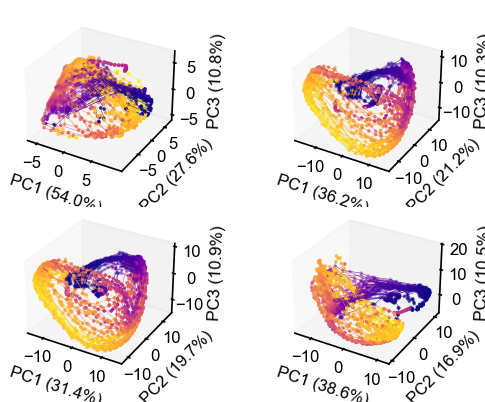

Global shoulder angle range: -0.436 to 1.387 radians


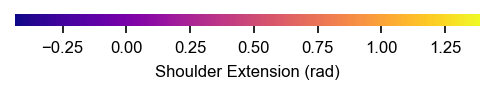

Global shoulder angle range: -0.436 to 1.387 radians


In [5]:
# Create a 2x2 subplot layout for all decoder layers and intentions
from matplotlib.figure import Figure
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from typing import List
import numpy as np

def plot_subplot(
    data: np.ndarray,
    color_array: np.ndarray,
    title: str,
    labels: List[str],
    ax,
    norm,
    cmap,
):
    """
    Plot a 3D trajectory with color-coded points and connecting line segments on a given axis.
    """
    ax.tick_params(axis="both", which="major", labelsize=8, pad=-4)
    ax.tick_params(axis="z", which="major", labelsize=8, pad=-3)

    # make the overall figure background white
    ax.set_facecolor("white")
    ax.grid(False)  # remove grid lines

    #ax.view_init(elev=40, azim=-60)

    # RESTORED: Use the tight axis limits from your original (this prevents zooming out)
    x_range = data[:, :, 0].max() - data[:, :, 0].min()
    y_range = data[:, :, 1].max() - data[:, :, 1].min()
    z_range = data[:, :, 2].max() - data[:, :, 2].min()

    ratio = -0.005

    ax.set_xlim(
        data[:, :, 0].min() - x_range * ratio, data[:, :, 0].max() + x_range * ratio
    )
    ax.set_ylim(
        data[:, :, 1].min() - y_range * ratio, data[:, :, 1].max() + y_range * ratio
    )
    ax.set_zlim(
        data[:, :, 2].min() - z_range * ratio, data[:, :, 2].max() + z_range * ratio
    )

    # add axis labels - match single plot styling exactly
    ax.set_xlabel(labels[0], fontsize=8, labelpad=-8, rotation=-16)
    ax.set_ylabel(labels[1], fontsize=8, labelpad=-8, rotation=55)
    ax.set_zlabel(labels[2], fontsize=8, labelpad=-8, rotation=90)

    # RESTORED: Use your original scatter size and linewidth
    for n in range(data.shape[0]):
        # define line color
        d = data[n]
        lc_color = cmap(norm(color_array[n, :-1]))
        line_data = np.stack([d[:-1], d[1:]], axis=1)
        lc = Line3DCollection(line_data, colors=lc_color, linewidths=0.2)  # Match original
        ax.add_collection3d(lc)
        ax.scatter(
            d[:, 0], d[:, 1], d[:, 2], c=color_array[n], cmap=cmap, norm=norm, s=0.5  # Match original s=0.5
        )

# Create data with shoulder extension angle as 4th dimension using your computed variables
decoder_0_with_angle = np.concatenate([decoder_layer_0, qpos_data[:, :, 2][..., np.newaxis]], axis=2)
decoder_1_with_angle = np.concatenate([decoder_layer_1, qpos_data[:, :, 2][..., np.newaxis]], axis=2)
decoder_2_with_angle = np.concatenate([decoder_layer_2, qpos_data[:, :, 2][..., np.newaxis]], axis=2)
intentions_with_angle = np.concatenate([intentions_pca, qpos_data[:, :, 2][..., np.newaxis]], axis=2)

# Dataset configurations using computed variables
datasets = {
    "intentions": {
        "data": intentions_with_angle,
        "title": "Intentions",
        "var_exp": vars_intentions_pca,
    },
    "decoder_layer_0": {
        "data": decoder_0_with_angle,
        "title": "Decoder Layer 1",
        "var_exp": vars_decoder_layer_0,
    },
    "decoder_layer_1": {
        "data": decoder_1_with_angle,
        "title": "Decoder Layer 2",
        "var_exp": vars_decoder_layer_1,
    },
    "decoder_layer_2": {
        "data": decoder_2_with_angle,
        "title": "Decoder Layer 3",
        "var_exp": vars_decoder_layer_2,
    },
}

# Find global min and max across all shoulder angles for consistent colorbar
all_shoulder_angles = []
for config in datasets.values():
    shoulder_angles = config["data"][:, :, 3]
    all_shoulder_angles.append(shoulder_angles)

global_min = min(angles.min() for angles in all_shoulder_angles)
global_max = max(angles.max() for angles in all_shoulder_angles)

# Create shared colormap and normalization
norm = plt.Normalize(global_min, global_max)
cmap = plt.cm.plasma

# Create 2x2 subplot figure - increase height slightly for better spacing
fig = plt.figure(figsize=(3.75, 3))  # Increased height from 3 to 4
fig.patch.set_facecolor("white")

subplot_positions = [(0, 0), (0, 1), (1, 0), (1, 1)]

for i, (key, config) in enumerate(datasets.items()):
    row, col = subplot_positions[i]
    ax = fig.add_subplot(2, 2, i + 1, projection="3d")

    plot_data = config["data"]
    var_exp = config["var_exp"]

    # Extract the 3D coordinates (first 3 dimensions) and shoulder extension angle (4th dimension)
    trajectory_data = plot_data[:, :, :3]  # Shape: (N, T, 3) - x, y, z coordinates
    shoulder_angles = plot_data[:, :, 3]  # Shape: (N, T) - shoulder extension angles

    # Create labels with explained variance percentages
    labels = [f"PC1 ({var_exp[0]:.1f}%)", f"PC2 ({var_exp[1]:.1f}%)", f"PC3 ({var_exp[2]:.1f}%)"]

    # Plot the 3D trajectory with shoulder extension angle as color
    plot_subplot(
        data=trajectory_data,
        color_array=shoulder_angles,
        title=config["title"],
        labels=labels,
        ax=ax,
        norm=norm,
        cmap=cmap,
    )

    # Fix ticks only for the top-left subplot (intentions)
    if key == "intentions":
        ax.set_xticks([-5, 0, 5])
        ax.set_yticks([-5, 0, 5])
        ax.set_zticks([-5, 0, 5])

    print(f"{config['title']} - Trajectory data shape: {trajectory_data.shape}")
    print(f"{config['title']} - Shoulder angles shape: {shoulder_angles.shape}")
    print(
        f"{config['title']} - Shoulder angle range: {shoulder_angles.min():.3f} to {shoulder_angles.max():.3f} radians"
    )

# Use subplots_adjust instead of tight_layout to add whitespace between rows
plt.subplots_adjust(
    left=0.00,     # Left margin
    right=0.95,    # Right margin
    top=0.90,      # Top margin
    bottom=0.10,   # Bottom margin
    wspace=0.0,   # Width spacing between columns (left-right)
    hspace=0.15    # Height spacing between rows (top-bottom) - this adds the whitespace!
)

plt.savefig("arm_latent_space_2x2.pdf", pad_inches=0.2)
plt.show()

print(f"Global shoulder angle range: {global_min:.3f} to {global_max:.3f} radians")

# Create a separate figure for the colorbar
fig_cbar, ax_cbar = plt.subplots(figsize=(4, 0.1))
fig_cbar.patch.set_facecolor("white")

# Create the colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, cax=ax_cbar, orientation="horizontal")
plt.tick_params(labelsize=8)
cbar.set_label("Shoulder Extension (rad)", fontsize=8)

# Remove the axis frame
ax_cbar.set_frame_on(False)
plt.savefig("fig5_arm_latent_space_colorbar.pdf", bbox_inches="tight")
plt.show()

print(f"Global shoulder angle range: {global_min:.3f} to {global_max:.3f} radians")